          Technique  Accuracy
0      Drop Missing  0.338548
1      Fill Missing  0.335250
2    Label Encoding  0.336875
3  One-Hot Encoding  0.342500
4   Without Scaling  0.342500
5      With Scaling  0.342875


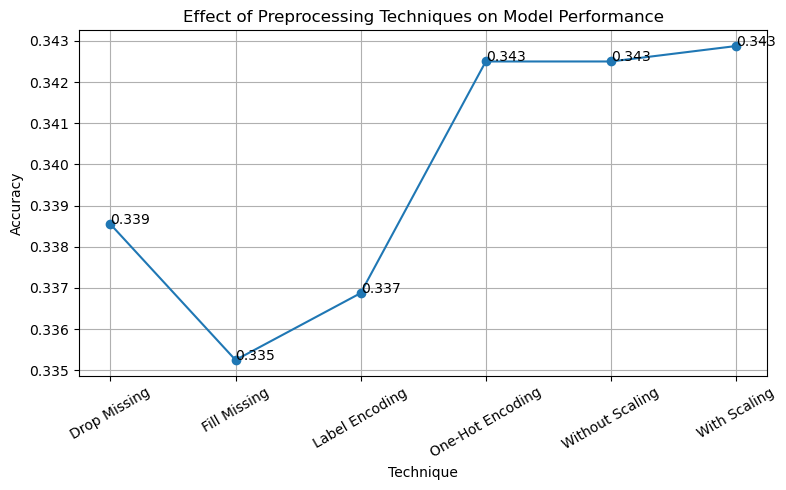

In [8]:

# RQ3: Effect of Preprocessing Techniques (FINAL IMPROVED)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. LOAD DATA

df = pd.read_csv('D:/University Of Europe/ML/Assignment 1/Cyber Security Attacks Dataset.csv')

# Select same columns
df = df[[
    'Source Port',
    'Destination Port',
    'Protocol',
    'Packet Length',
    'Packet Type',
    'Traffic Type',
    'Anomaly Scores',
    'Attack Type'
]]

# 2. CREATE BASE DATASET (SAME FOR ALL)

# Introduce missing values once
df_base = df.copy()
df_base.iloc[0:50, 0] = np.nan

# Target
target = "Attack Type"

# 3. FIX TRAIN-TEST SPLIT (IMPORTANT)

# Use same split indices
train_idx, test_idx = train_test_split(df_base.index, test_size=0.2, random_state=42)

# 4. EXPERIMENT FUNCTION

def evaluate_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    
    return accuracy_score(y_test, model.predict(X_test))

# 5. EXPERIMENTS

results = []

# A. Missing Values

# Drop missing
df_drop = df_base.dropna()
X = pd.get_dummies(df_drop.drop(target, axis=1), drop_first=True)
y = df_drop[target]

acc = evaluate_model(X, y)
results.append(["Drop Missing", acc])

# Fill missing
df_fill = df_base.fillna(df_base.mean(numeric_only=True))
X = pd.get_dummies(df_fill.drop(target, axis=1), drop_first=True)
y = df_fill[target]

acc = evaluate_model(X, y)
results.append(["Fill Missing", acc])


# B. Encoding

# Label Encoding
df_enc = df.fillna(df.mean(numeric_only=True)).copy()

le = LabelEncoder()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.drop(target, axis=1)
y = df_enc[target]

acc = evaluate_model(X, y)
results.append(["Label Encoding", acc])


# One-Hot Encoding
df_ohe = df.fillna(df.mean(numeric_only=True))
X = pd.get_dummies(df_ohe.drop(target, axis=1), drop_first=True)
y = df_ohe[target]

acc = evaluate_model(X, y)
results.append(["One-Hot Encoding", acc])


# C. Scaling

df_scale = df.fillna(df.mean(numeric_only=True))
X = pd.get_dummies(df_scale.drop(target, axis=1), drop_first=True)
y = df_scale[target]

# Without scaling
acc = evaluate_model(X, y)
results.append(["Without Scaling", acc])

# With scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

acc = evaluate_model(X_scaled, y)
results.append(["With Scaling", acc])


# 6. SAVE RESULTS

df_results = pd.DataFrame(results, columns=["Technique", "Accuracy"])
print(df_results)

df_results.to_csv("RQ3_results.csv", index=False)


# 7. PLOT

plt.figure(figsize=(8,5))
plt.plot(df_results["Technique"], df_results["Accuracy"], marker='o')

for i, v in enumerate(df_results["Accuracy"]):
    plt.text(i, v, f"{v:.3f}")

plt.xticks(rotation=30)
plt.title("Effect of Preprocessing Techniques on Model Performance")
plt.xlabel("Technique")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.savefig("RQ3_figure.pdf")
plt.show()